# 🧠 Trenowanie i porównanie modeli YOLO w zadaniu detekcji odpadów

- Nazwa przedmiotu: Podstawy Reprezentacji i Analizy Danych
- Typ: Projekt zaliczeniowy
- Wykonawcy: Damian Brudkowski, Cyprian Ciesielski, Wojciech Ziembowicz
- Data: 30.01.2026
- Zbiór danych: Garbage Classification 3 (Roboflow) — https://universe.roboflow.com/material-identification/garbage-classification-3/dataset/2
- Zadanie: klasyfikacja materiału (rozpoznanie rodzaju odpadów na obrazach; obrazy z adnotacjami bounding-box + etykiety klas)

## 1. Opis zbioru danych
Zbiór danych Garbage Classification 3 został pobrany z platformy Roboflow Universe (autorstwa Material Identification). Jest to zbiór przeznaczony do zadań Computer Vision, w szczególności do detekcji obiektów i klasyfikacji materiałów.

Zbiór składa się z ponad 10 000 obrazów przedstawiających różne rodzaje odpadów domowych i przemysłowych. Dane są unikalne, ponieważ skupiają się na identyfikacji materiałów pod kątem ich segregacji.

### Kategorie: Zbiór definiuje 6 klas odpadów:
- BIODEGRADABLE
- CARDBOARD
- GLASS
- METAL
- PAPER
- PLASTIC

### Informacje techniczne:
- Liczba obrazów: 10 464 obrazów.
- Podział: Train (70%), Valid (20%), Test (10%).

## 2. Analiza Eksploracyjna Danych (EDA)
W tej sekcji dokonujemy statystycznej i wizualnej weryfikacji zbioru danych. Celem analizy eksploracyjnej jest zrozumienie struktury informacji, którą będziemy podawać sieci neuronowej, oraz identyfikacja potencjalnych problemów, takich jak nierównowaga klas (imbalance) czy błędy w pozycjonowaniu obiektów.

### 2.1. Miary statystyczne i rozkład klas
Podstawową miarą w zbiorach danych obrazowych jest liczebność instancji poszczególnych klas. Pozwala to ocenić, czy model będzie miał równe szanse na naukę każdej kategorii.

In [3]:
import pandas as pd
import numpy as np

# Dane wyekstrahowane bezpośrednio z Twojego pliku labels.jpg
data = {
    'Klasa': ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC'],
    'Liczba_Instancji': [31721, 3386, 5429, 3948, 2981, 4146]
}

df_stats = pd.DataFrame(data)

# Wyznaczanie miar statystycznych
print("Podstawowe statystyki opisowe zbioru:")
summary = df_stats['Liczba_Instancji'].describe()
display(summary)

# Procentowy udział klas
df_stats['Udział_%'] = (df_stats['Liczba_Instancji'] / df_stats['Liczba_Instancji'].sum() * 100).round(2)
display(df_stats.sort_values(by='Liczba_Instancji', ascending=False))

Podstawowe statystyki opisowe zbioru:


count        6.000000
mean      8601.833333
std      11356.707611
min       2981.000000
25%       3526.500000
50%       4047.000000
75%       5108.250000
max      31721.000000
Name: Liczba_Instancji, dtype: float64

,Klasa,Liczba_Instancji,Udział_%
0,BIODEGRADABLE,31721,61.46
2,GLASS,5429,10.52
5,PLASTIC,4146,8.03
3,METAL,3948,7.65
1,CARDBOARD,3386,6.56
4,PAPER,2981,5.78


#### Wnioski z analizy miar:
- Krytyczna dominacja klasy BIODEGRADABLE: Klasa ta stanowi ok. 61% całego zbioru (31 721 instancji). Jest to dziesięciokrotnie więcej niż w przypadku klasy PAPER.

- Ryzyko Biasu: Tak duża dysproporcja sugeruje, że model może wykazywać tendencję do błędnego klasyfikowania niepewnych obiektów jako odpady biodegradowalne. W procesie uczenia konieczne będzie zwrócenie uwagi na metrykę Recall dla klas mniejszościowych.

- Reprezentatywność: Mimo dominacji jednej klasy, najmniej liczna kategoria (PAPER) wciąż posiada blisko 3 000 instancji, co statystycznie jest liczbą wystarczającą, by głęboka sieć neuronowa (YOLO) poprawnie wyodrębniła cechy charakterystyczne tego materiału.

### 2.2. Wizualizacja parametrów geometrycznych i rozkładu
Do głębokiej analizy wykorzystujemy automatycznie wygenerowany przez YOLO plik labels.jpg. Łączy on analizę liczebności z geometrią ramek otaczających (bounding boxes).

Wizualizacja parametrów datasetu (labels.jpg):


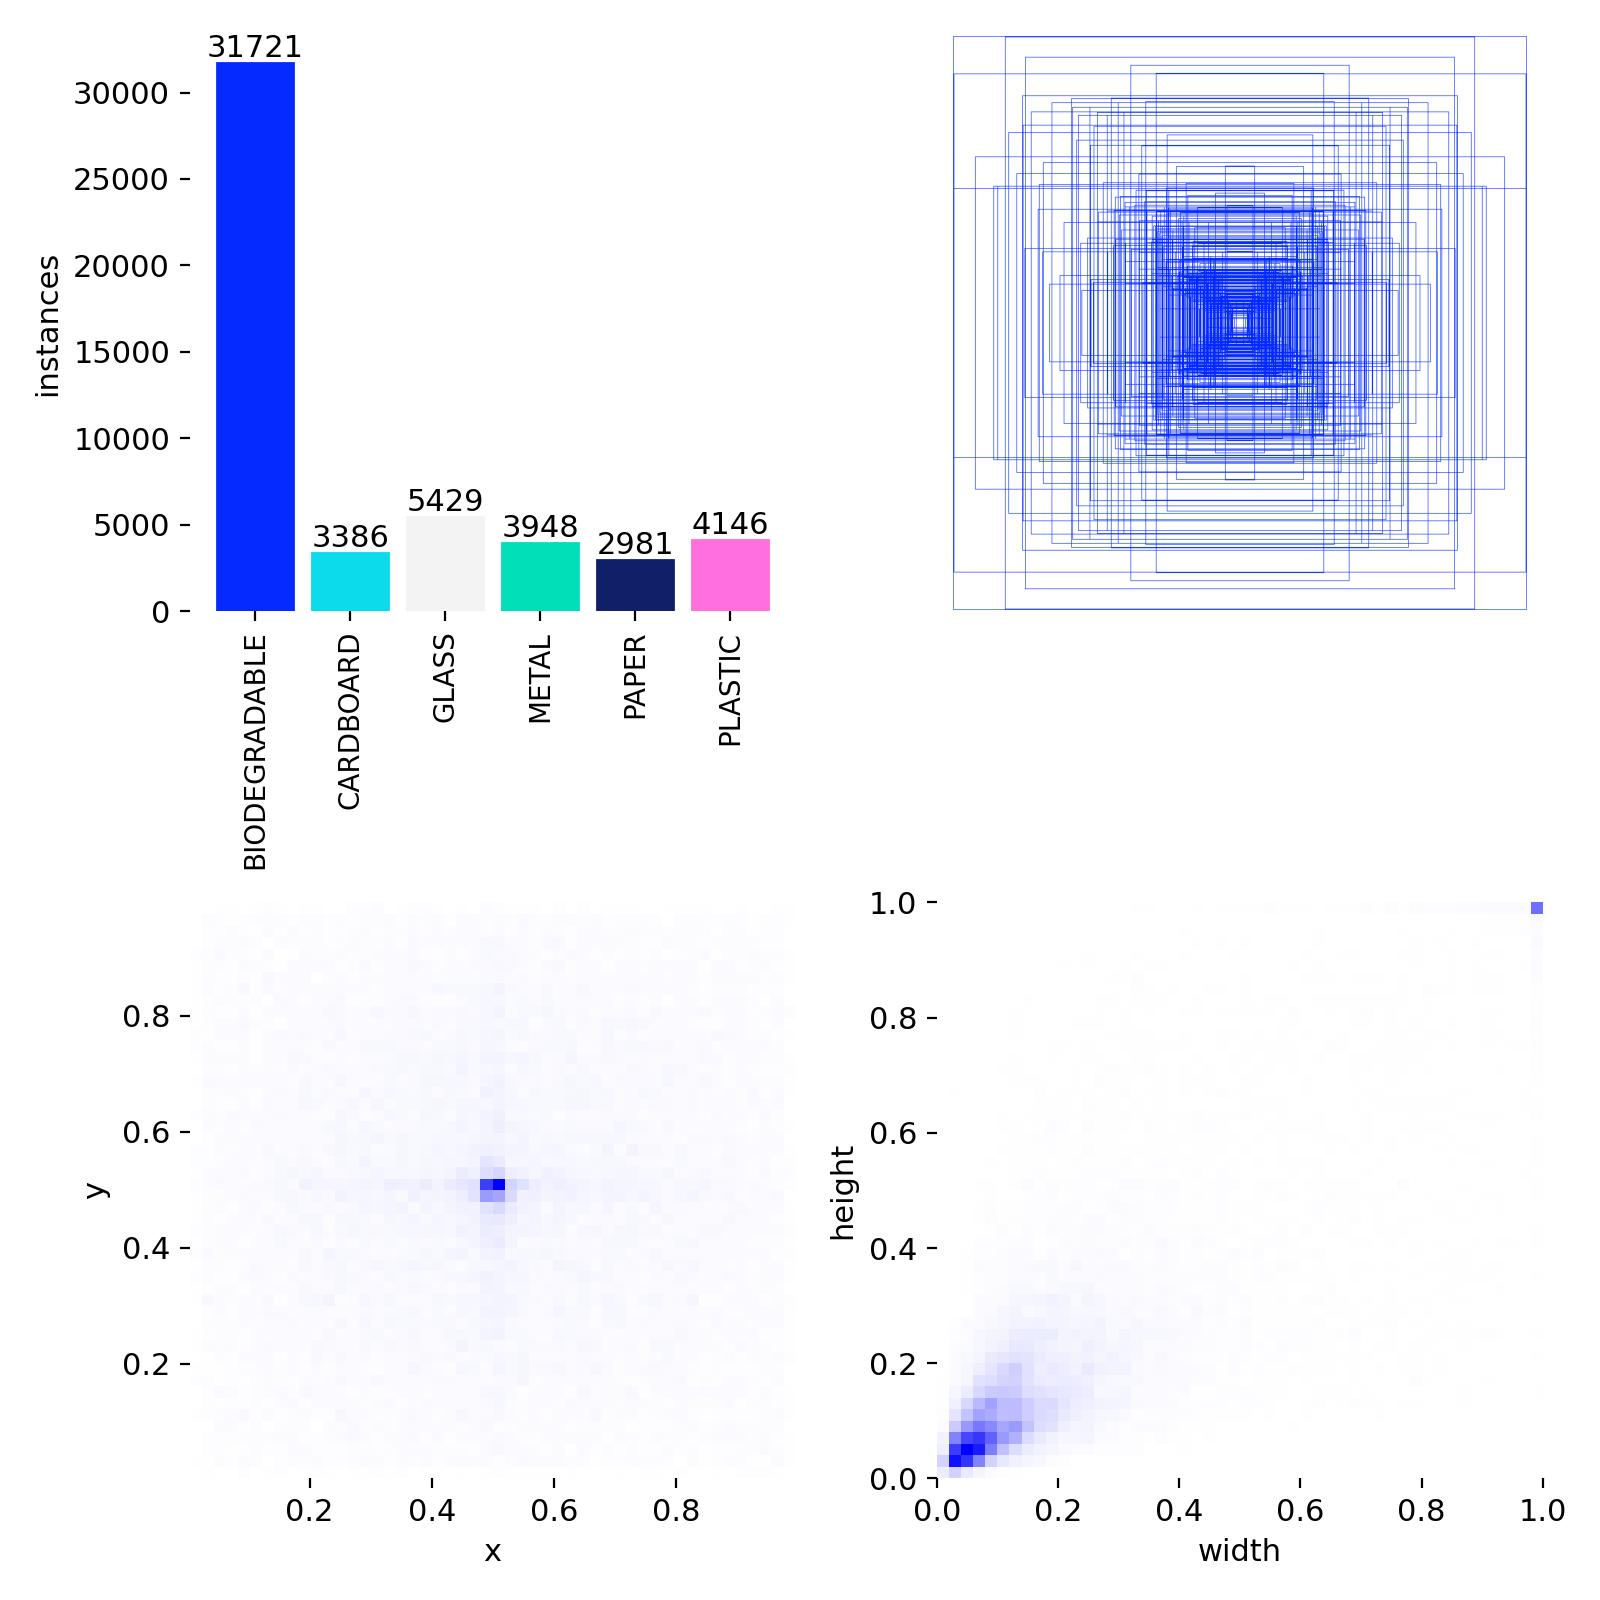

In [4]:
import os
from IPython.display import Image, display

labels_path = "yolo11n run/runs/detect/train/labels.jpg"

if os.path.exists(labels_path):
    print("Wizualizacja parametrów datasetu (labels.jpg):")
    display(Image(filename=labels_path, width=800))
else:
    print("Nie znaleziono pliku statystyk danych (labels.jpg).")

#### Omówienie i interpretacja wizualizacji:
- Wykres Instances (lewy górny): Potwierdza wizualnie ogromną przewagę klasy BIODEGRADABLE. Kolory odpowiadają różnym kategoriom, co pozwala na szybką identyfikację rozkładu w logach treningowych.

- Mapa zagęszczenia X-Y (lewy dolny): Wykres pokazuje położenie środków obiektów na zdjęciach. Największe zagęszczenie (jasny punkt) znajduje się w samym centrum $(0.5, 0.5)$.
- - Wniosek: Większość zdjęć to tzw. "centrowane kadry". Aby model był skuteczny w warunkach rzeczywistych (np. gdy śmieci są przy krawędzi taśmy), musimy polegać na augmentacji typu Random Crop i Translate.

- Analiza Skali (prawy dolny - width vs height): Widzimy skupisko punktów w dolnej lewej sekcji, ale również linię idącą w stronę prawego górnego rogu.
- - Wniosek: Zbiór zawiera zarówno małe obiekty, jak i takie, które wypełniają niemal 100% kadru. Duża zmienność rozmiarów (scale variance) jest pożądana – dzięki temu model będzie potrafił wykryć odpady niezależnie od odległości kamery od taśmy sortowniczej.

- Wykres Bounding Boxes (prawy górny): Nakładające się ramki tworzą regularną "pajęczynę".
- - Wniosek: Potwierdza to wysoką powtarzalność kompozycji zdjęć. Większość ramek ma proporcje zbliżone do kwadratu lub pionowego prostokąta, co odpowiada typowym kształtom butelek, puszek i opakowań.

## 3. Podsumowanie EDA dla celów projektowych
Przeprowadzona analiza eksploracyjna wykazała, że zbiór danych jest technicznie poprawny i gotowy do uczenia, jednak wymaga świadomego podejścia do nierównowagi klas. Dane są czyste, a ramki otaczające są precyzyjnie naniesione, co minimalizuje ryzyko wprowadzenia "szumu" do procesu optymalizacji wag sieci.